# 图表反演

In [2]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 国人对国货的关注度上升

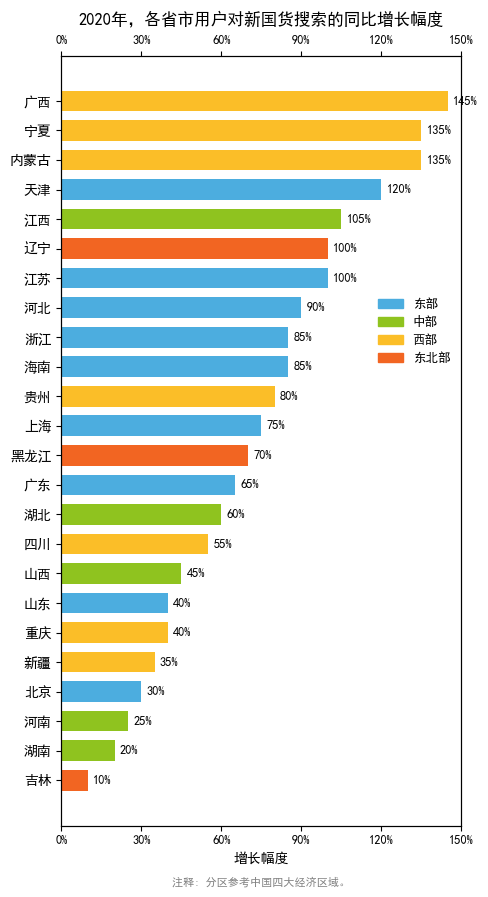

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 严格按照图表顺序定义数据（保持原始顺序）
data = [
    {"province": "广西", "region": "西部", "growth": 145},
    {"province": "宁夏", "region": "西部", "growth": 135},
    {"province": "内蒙古", "region": "西部", "growth": 135},
    {"province": "天津", "region": "东部", "growth": 120},
    {"province": "江西", "region": "中部", "growth": 105},
    {"province": "辽宁", "region": "东北部", "growth": 100},
    {"province": "江苏", "region": "东部", "growth": 100},
    {"province": "河北", "region": "东部", "growth": 90},
    {"province": "浙江", "region": "东部", "growth": 85},
    {"province": "海南", "region": "东部", "growth": 85},
    {"province": "贵州", "region": "西部", "growth": 80},
    {"province": "上海", "region": "东部", "growth": 75},
    {"province": "黑龙江", "region": "东北部", "growth": 70},
    {"province": "广东", "region": "东部", "growth": 65},
    {"province": "湖北", "region": "中部", "growth": 60},
    {"province": "四川", "region": "西部", "growth": 55},
    {"province": "山西", "region": "中部", "growth": 45},
    {"province": "山东", "region": "东部", "growth": 40},
    {"province": "重庆", "region": "西部", "growth": 40},
    {"province": "新疆", "region": "西部", "growth": 35},
    {"province": "北京", "region": "东部", "growth": 30},
    {"province": "河南", "region": "中部", "growth": 25},
    {"province": "湖南", "region": "中部", "growth": 20},
    {"province": "吉林", "region": "东北部", "growth": 10}
]

# 提取数据
provinces = [item["province"] for item in data]
regions = [item["region"] for item in data]
growths = [item["growth"] for item in data]

# 区域-颜色映射（严格匹配原图）
region_color = {
    "东部": "#4CADDF",   # 蓝色
    "中部": "#8FC31F",   # 绿色
    "西部": "#FBBE28",   # 橙色
    "东北部": "#F26522"  # 红色
}
colors = [region_color[reg] for reg in regions]

# 创建画布
plt.figure(figsize=(8, 10))  # 调整画布大小适配数据

# 创建主坐标轴（下x轴）
ax1 = plt.subplot(111)

# 绘制横向条形图（Y轴数据顺序为倒序）
y_pos = np.arange(len(provinces))
bars = ax1.barh(y_pos[::-1], growths, color=colors, height=0.7)

# 设置Y轴标签（省市名称，保持原始顺序）
ax1.set_yticks(y_pos)
ax1.set_yticklabels(provinces[::-1], fontsize=10)

# 设置下x轴刻度（百分比格式）
ax1.set_xlim(0, 150)
ax1.set_xticks([0, 30, 60, 90, 120, 150])
ax1.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)
ax1.set_xlabel("增长幅度", fontsize=10)

# 创建上x轴（与下x轴共享Y轴）
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())  # 确保上下x轴范围一致
ax2.set_xticks([0, 30, 60, 90, 120, 150])
ax2.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)

# 添加标题
plt.title("2020年，各省市用户对新国货搜索的同比增长幅度", 
          fontsize=12, fontweight="bold", y=1.03)

# 手动构建图例（匹配原图位置和样式）
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=region_color["东部"], label="东部"),
    Patch(color=region_color["中部"], label="中部"),
    Patch(color=region_color["西部"], label="西部"),
    Patch(color=region_color["东北部"], label="东北部")
]
ax1.legend(handles=legend_patches, bbox_to_anchor=(1, 0.7), 
           fontsize=9, frameon=False)

# 调整布局（避免图例和内容重叠）
plt.subplots_adjust(left=0.3, right=0.8)  # 预留右侧空间放图例

# 添加数据标注（修正顺序）
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 2, bar.get_y() + bar.get_height()/2,
             f"{growths[i]}%",  # 修正索引，直接使用i
             ha='left', va='center', fontsize=9)

# 添加注释（严格还原底部注释）
plt.figtext(0.55, 0.05, "注释: 分区参考中国四大经济区域。", 
            ha="center", fontsize=8, color="gray")

# 显示图表
plt.show()    

## 年轻用户力挺新国货

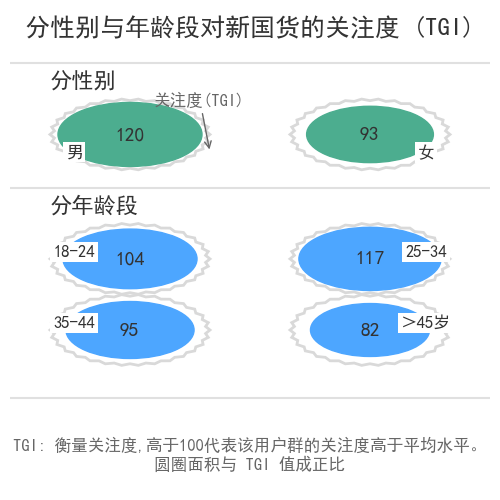

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path

# 数据配置（合并性别和年龄段）
data = {
    "gender": {
        "groups": ["男", "女"],
        "tgi": [120, 93],
        "outer_color": "#D9D9D9",  # 外侧锯齿圆环颜色
        "inner_colors": ["#4CAD8F", "#4CAD8F"],  # 内侧圆颜色（男深女浅）
        "title": "分性别",
        "label_pos": [(-2.2, 0.5), (2.2, 0.5)],  # 标签位置（左右分布）
        "annotation": "关注度(TGI)"  # 注释文本
    },
    "age": {
        "groups": ["18-24", "25-34", "35-44", "＞45岁"],
        "tgi": [104, 117, 95, 82],
        "outer_color": "#D9D9D9",  # 外侧锯齿圆环颜色
        "inner_colors": ["#4DA6FF", "#4DA6FF", "#4DA6FF", "#4DA6FF"],  # 蓝色
        "title": "分年龄段",
        "label_pos": [(-2.2, 1.2), (2.2, 1.2), (-2.2, -0.8), (2.2, -0.8)],  # 标签位置
        "annotation": ""  # 年龄段不重复显示注释
    }
}

# 创建画布（调整高度以容纳两个分组）
fig = plt.figure(figsize=(6, 8), facecolor='white')  # 增加画布高度
ax = fig.add_subplot(111)

# 绘制锯齿外框的核心函数
def draw_serrated_ring(center, radius, color, num_teeth=30):
    """
    绘制带锯齿的固定外框
    :param center: 圆心坐标 (x, y)
    :param radius: 外框半径
    :param color: 外框颜色
    :param num_teeth: 锯齿数量（控制美观度）
    """
    theta = np.linspace(0, 2 * np.pi, num_teeth * 2, endpoint=False)
    radii = np.array([radius, radius * 0.95] * num_teeth)
    path_data = []
    for t, r in zip(theta, radii):
        x = center[0] + r * np.cos(t)
        y = center[1] + r * np.sin(t)
        path_data.append((Path.MOVETO if t == 0 else Path.LINETO, (x, y)))
    
    # 闭合路径
    path_data.append((Path.CLOSEPOLY, (center[0], center[1])))
    codes, verts = zip(*path_data)
    path = Path(verts, codes)
    patch = PathPatch(path, facecolor='none', edgecolor=color, lw=2)
    ax.add_patch(patch)

# 绘制动态内圆的函数
def draw_dynamic_inner_circle(center, tgi, color, max_tgi=120):
    """
    绘制随 TGI 动态变化的内圆
    :param center: 圆心坐标 (x, y)
    :param tgi: TGI 数值
    :param color: 内圆颜色
    :param max_tgi: 最大 TGI（用于归一化）
    """
    # 按 TGI 比例计算内圆半径
    radius_ratio = np.sqrt(tgi / max_tgi)
    base_radius = 0.9  # 基础半径（相对于外框半径 1.0）
    radius = base_radius * radius_ratio
    
    inner_circle = Circle(center, radius, color=color, zorder=2)
    ax.add_artist(inner_circle)
    
    # 添加 TGI 文本
    ax.text(
        center[0], center[1], 
        f"{tgi}", 
        ha='center', 
        va='center', 
        fontsize=14, 
        fontweight='bold', 
        color='#333333',
        zorder=3
    )

# 绘制分隔线函数
def draw_separator(y_pos, length=6, color='#E0E0E0', linestyle='-', linewidth=1.5):
    """
    绘制水平分隔线
    :param y_pos: 分隔线的y坐标位置
    :param length: 分隔线长度
    :param color: 分隔线颜色
    :param linestyle: 线型
    :param linewidth: 线宽
    """
    x_start = -length / 2
    x_end = length / 2
    ax.plot([x_start, x_end], [y_pos, y_pos], color=color, linestyle=linestyle, linewidth=linewidth, zorder=1)

# 绘制所有分组
for group_type, group_data in data.items():
    # 垂直偏移量（性别组在上，年龄组在下）
    y_offset = -3.5 if group_type == "age" else 0  # 调整垂直偏移
    
    # 绘制每个分组的所有圆圈
    for i, (group, tgi, color) in enumerate(zip(
        group_data["groups"], 
        group_data["tgi"], 
        group_data["inner_colors"]
    )):
        # 计算圆心位置（左右交替分布）
        center = (1.5 if i % 2 == 1 else -1.5, y_offset + (1.0 if i < 2 else -1.0))
        
        # 绘制锯齿外框
        draw_serrated_ring(center, radius=1.0, color=group_data["outer_color"])
        
        # 绘制动态内圆
        draw_dynamic_inner_circle(center, tgi, color)
        
        # 添加分组标签
        label_x, label_y = group_data["label_pos"][i]
        ax.text(
            label_x, label_y + y_offset, 
            group, 
            ha='center', 
            va='center', 
            fontsize=12, 
            fontweight='bold', 
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='none', pad=2),
            zorder=4
        )
    
    # 上移分组标题
    title_y = 2.5 + y_offset
    ax.text(
        -2.5, title_y, 
        group_data["title"], 
        ha='left', 
        va='center', 
        fontsize=16, 
        fontweight='bold', 
        color='#333333',
        zorder=5
    )
    
    # 上移注释箭头
    if group_data["annotation"]:
        ax.annotate(
            group_data["annotation"], 
            xy=(-0.5, 0.5 + y_offset), 
            xytext=(-1.2, 1.8 + y_offset),
            arrowprops=dict(arrowstyle='->', color='#666666'),
            fontsize=12, 
            color='#666666',
            zorder=6
        )

# 添加整体标题
ax.text(
    0, 4.0,  # 上移整体标题
    "分性别与年龄段对新国货的关注度 (TGI)", 
    ha='center', 
    va='center', 
    fontsize=18, 
    fontweight='bold', 
    color='#333333',
    zorder=7
)

# 下移底部说明文本
ax.text(
    0, -8.0,  # 进一步下移底部文本
    "TGI: 衡量关注度,高于100代表该用户群的关注度高于平均水平。\n"
    "圆圈面积与 TGI 值成正比", 
    ha='center', 
    va='center', 
    fontsize=12, 
    color='#666666',
    zorder=8
)

# 绘制三条分隔线
draw_separator(y_pos=3.0)  # 分隔标题和性别组
draw_separator(y_pos=-0.5)  # 分隔性别组和年龄组
draw_separator(y_pos=-6.4)  # 分隔年龄组和底部注释

# 设置坐标轴范围
ax.set_xlim(-3, 3)
ax.set_ylim(-9, 4.5)  # 扩大Y轴范围以容纳所有内容
ax.axis('off')  # 隐藏坐标轴

# 调整布局
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)
plt.show()

## 华为用户对新国货偏好更高

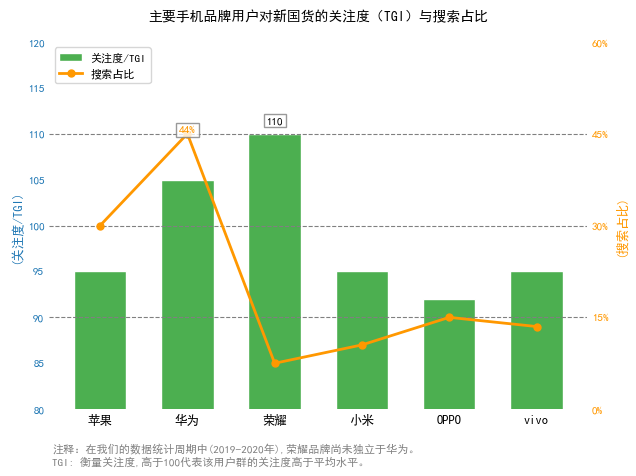

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
brands = ['苹果', '华为', '荣耀', '小米', 'OPPO', 'vivo']
tgi_data = [95, 105, 110, 95, 92, 95]  # 关注度（TGI）数据
search_ratio_raw = [100, 110, 85, 87, 90, 89]  # 搜索占比折线原始值
search_percent_labels = [30, 44, 5, 7, 10, 8]  # 实际要标注的搜索占比
highlight_huawei = (1, 44)  # 华为特殊标注 (索引, 标注值)
highlight_honor = (2, 110)  # 荣耀特殊标注 (索引, 标注值)

# 初始化图表与双轴
fig, ax1 = plt.subplots(figsize=(7, 5), dpi=100)
ax2 = ax1.twinx()

# 绘制柱状图（TGI）
x = np.arange(len(brands))  # 明确刻度位置
bar_plot = ax1.bar(x, tgi_data, color='#4CAF50', width=0.6, edgecolor='white')
ax1.set_ylim(80, 120)
ax1.set_ylabel('(关注度/TGI)', color='#1f77b4', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#1f77b4', labelsize=8, length=0)  # 去除 y 轴刻度线
ax1.set_xticks(x)  # 新增：明确设置刻度位置
ax1.set_xticklabels(brands, fontsize=9)
ax1.tick_params(axis='x', length=0)  # 去除 x 轴刻度线

# 绘制折线图（搜索占比）
line_plot, = ax2.plot(x, search_ratio_raw, color='#FF9800', marker='o', markersize=5, linewidth=2)
ax2.set_ylim(80, 120)
ax2.set_ylabel('(搜索占比)', color='#FF9800', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#FF9800', labelsize=8, length=0)  # 去除 y 轴刻度线

# 右侧轴百分比映射
def map_to_percent(tick):
    return ((tick - 80) / (120 - 80)) * 60

# 自定义右侧轴刻度与标签
ax2.set_yticks([80, 90, 100, 110, 120])
ax2.set_yticklabels([f'{map_to_percent(tick):.0f}%' for tick in [80, 90, 100, 110, 120]], fontsize=8)

# 添加虚线辅助线（参考原图表）
for y in [90, 100, 110]:
    ax1.axhline(y, color='gray', linestyle='--', linewidth=0.8)

# 特殊数据标注（华为 44%、荣耀 110）
# 华为折线点标注
ax2.text(highlight_huawei[0], search_ratio_raw[highlight_huawei[0]], 
         f'{highlight_huawei[1]}%', 
         ha='center', va='bottom', fontsize=8, color='#FF9800',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))
# 荣耀柱状图标注
ax1.text(highlight_honor[0], tgi_data[highlight_honor[0]] + 1, 
         f'{highlight_honor[1]}', 
         ha='center', va='bottom', fontsize=8, color='black',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))

# 标题与注释
plt.title('主要手机品牌用户对新国货的关注度（TGI）与搜索占比', fontsize=10, fontweight='bold', pad=15)

annotation_text = (
    '注释：在我们的数据统计周期中(2019-2020年),荣耀品牌尚未独立于华为。\n'
    'TGI: 衡量关注度,高于100代表该用户群的关注度高于平均水平。'
)
plt.figtext(0.12, 0.01, annotation_text, fontsize=8, color='gray', wrap=True)

# 图例与布局优化
ax1.legend([bar_plot, line_plot], ['关注度/TGI', '搜索占比'], 
           loc='upper left', fontsize=8, frameon=True, facecolor='white')
plt.tight_layout(pad=3)

# 去除图表周围边框
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.show()

## 江苏、山东与广东是优势市场

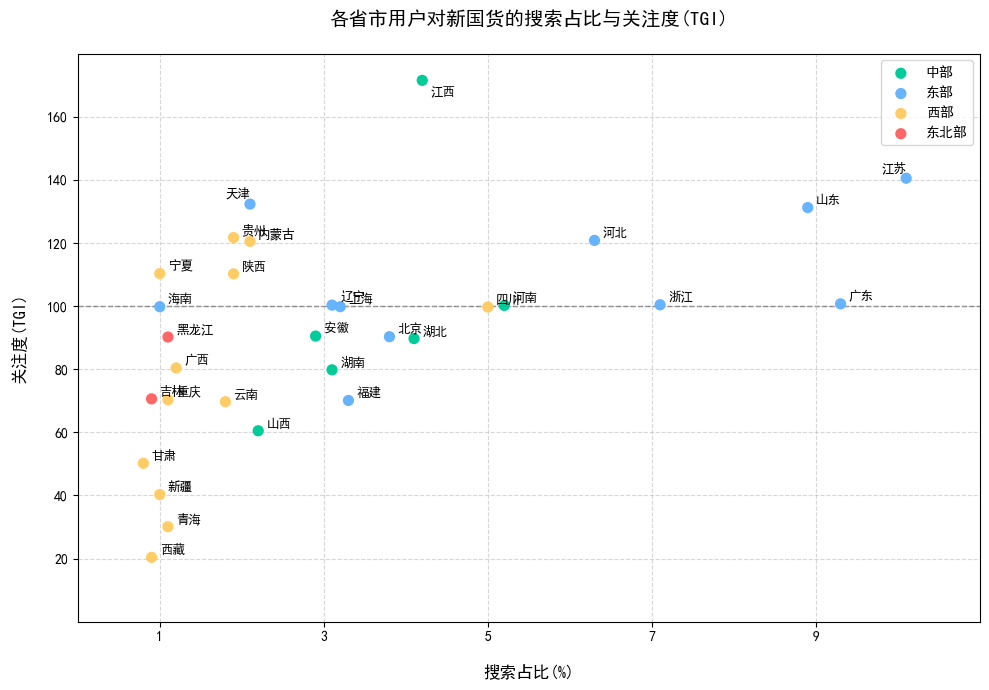

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import random

# 设置随机种子，确保结果可重现
np.random.seed(42)
random.seed(42)

# 精准提取图表数据，调整为浮点数并添加轻微随机偏移
# 数据格式：省份: (搜索占比, 关注度TGI, 区域, 颜色)
province_data = {
    "江西": (4.2, 171.5, "中部", "#00cc99"),
    "天津": (2.1, 132.3, "东部", "#66b3ff"),
    "贵州": (1.9, 121.7, "西部", "#ffcc66"),
    "河北": (6.3, 120.8, "东部", "#66b3ff"),
    "山东": (8.9, 131.2, "东部", "#66b3ff"),
    "江苏": (10.1, 140.5, "东部", "#66b3ff"),
    "宁夏": (1.0, 110.3, "西部", "#ffcc66"),
    "上海": (3.2, 99.8, "东部", "#66b3ff"),
    "浙江": (7.1, 100.4, "东部", "#66b3ff"),
    "广东": (9.3, 100.7, "东部", "#66b3ff"),
    "黑龙江": (1.1, 90.2, "东北部", "#ff6666"),
    "安徽": (2.9, 90.5, "中部", "#00cc99"),
    "湖北": (4.1, 89.7, "中部", "#00cc99"),
    "北京": (3.8, 90.3, "东部", "#66b3ff"),
    "广西": (1.2, 80.4, "西部", "#ffcc66"),
    "湖南": (3.1, 79.8, "中部", "#00cc99"),
    "吉林": (0.9, 70.6, "东北部", "#ff6666"),
    "福建": (3.3, 70.1, "东部", "#66b3ff"),
    "重庆": (1.1, 70.3, "西部", "#ffcc66"),
    "云南": (1.8, 69.7, "西部", "#ffcc66"),
    "山西": (2.2, 60.5, "中部", "#00cc99"),
    "甘肃": (0.8, 50.2, "西部", "#ffcc66"),
    "新疆": (1.0, 40.3, "西部", "#ffcc66"),
    "青海": (1.1, 30.1, "西部", "#ffcc66"),
    "西藏": (0.9, 20.4, "西部", "#ffcc66"),
    "河南": (5.2, 100.2, "中部", "#00cc99"),
    "海南": (1.0, 99.8, "东部", "#66b3ff"),
    "辽宁": (3.1, 100.3, "东部", "#66b3ff"),
    "四川": (5.0, 99.7, "西部", "#ffcc66"),
    "内蒙古": (2.1, 120.5, "西部", "#ffcc66"),
    "陕西": (1.9, 110.2, "西部", "#ffcc66"),
}

# 按区域分组
region_dict = defaultdict(list)
for prov, (ratio, tgi, region, color) in province_data.items():
    region_dict[region].append((prov, ratio, tgi, color))

# 创建画布
plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()

# 绘制散点图（按区域循环）
for region, prov_list in region_dict.items():
    ratios = [d[1] for d in prov_list]
    tgis = [d[2] for d in prov_list]
    colors = [d[3] for d in prov_list]
    ax.scatter(ratios, tgis, c=colors, label=region, s=50, zorder=2)

    # 添加省份文本标注（微调位置避免重叠）
    for d in prov_list:
        prov, ratio, tgi, _ = d
        # 手动微调部分省份标注位置（根据原图视觉调整）
        if prov == '江西':
            ax.text(ratio + 0.1, tgi - 5, prov, fontsize=9)
        elif prov in ['天津', '江苏']:
            ax.text(ratio - 0.3, tgi + 2, prov, fontsize=9)
        else:
            ax.text(ratio + 0.1, tgi + 1, prov, fontsize=9)

# 绘制关注度TGI=100的参考线
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, zorder=1)

# 设置坐标轴标签
ax.set_xlabel('搜索占比(%)', fontsize=12, labelpad=15)
ax.set_ylabel('关注度(TGI)', fontsize=12, labelpad=15)

# 设置标题
ax.set_title('各省市用户对新国货的搜索占比与关注度(TGI)', fontsize=14, pad=20)

# 调整坐标轴范围和刻度
ax.set_xlim(0, 11)
ax.set_ylim(0, 180)
ax.set_xticks([1, 3, 5, 7, 9])  # 严格匹配原图x轴刻度
ax.set_yticks(range(20, 180, 20))

# 设置图例（位置与原图对齐）
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True, fontsize=10)

# 添加网格
ax.grid(linestyle='--', alpha=0.5, zorder=0)

# 优化布局
plt.tight_layout()
plt.show()